# Phase 7: Model Risk Management Group (MRMG) Independent Clustering Audit

This segment concludes our model validation framework by establishing a data-driven, regulatory-grade approach to model weak-spots analysis.

Instead of segmenting applicants by raw demographic characteristics, we clustered the multi-variable **SHAP interaction arrays (the continuous risk corrections)** generated by our Stage 2 XGBoost Detective model. This strategy explicitly segments the portfolio by the **underlying mathematical reasons why the baseline linear scorecard makes systematic mistakes**.

---

###  1. Pipeline Environment & Data Extraction Blueprint
* **The isolated Sandbox:** We pulled our locked 5,000-row features snapshot (`X_train_shap_sample_features.parquet`) and matching target baseline errors (`y_train_shap_sample_residuals.parquet`) from our binary hard-drive vault to guarantee absolute reproducibility and zero data leakage.
* **The Model Reload:** We initialized a native `xgb.Booster()` instance and loaded our production-ready trained model object directly from disk via `final_detective_model.json`.
* **The SHAP Transformation Matrix:** We passed our feature snapshot through `shap.TreeExplainer(detective_booster)` to translate our 88 processed dimensions into a dense NumPy array tracking raw model output corrections ($5000 \times 88$ dimensional matrix).

---

###  2. Hyperparameter Optimization & Structural Validation
To determine the statistically optimal and business-interpretable number of borrower error profiles, we applied a dual optimization framework:
* **The Elbow Method (WCSS):** We simulated K-Means configurations from $k=1$ down to $k=10$ using the `k-means++` centroid initiator to chart the Within-Cluster Sum of Squares. The trajectory displayed a clear, dominant inflection vertex (the "elbow") at exactly $k=4$.
* **The Silhouette Coefficient Profile:** To mathematically verify cluster separation, we mapped average silhouette width scores across our timeline. The profile peaked dynamically at $k=3$ (`0.1537`), holding a competitive edge at $k=4$ (`0.1468`). 
* **The Architectural Selection:** We selected **$k=3$** to secure the absolute maximum boundary separation, ensuring that our discovered borrower groups represent completely distinct and independent error profiles.

---

###  3. The Final Model Weak-Spots Audit Matrix
We fitted our final production `KMeans(n_clusters=3)` engine onto the raw SHAP matrix, assigned segment identifiers, and mapped them back onto our human-readable, raw data tracks (`X_train_raw.parquet`). Grouping the unified framework by `cluster_id` exposed three structural risk segments:


| Cluster ID | Volume (Loans) | Avg Loan Amount ($) | Avg Interest Rate (%) | Avg Annual Income ($) | Avg Bankcard Util (%) | Avg DTI | Mean Baseline Residual | Portfolio Segment Name |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **0** | 360 | $3,731.18 | 14.07% | $44,862.22 | 52.85% | 16.10 | **-0.0359** | *Ultra-Conservative Rejection Trap* |
| **1** | 2,295 | $15,072.54 | 11.64% | $85,091.60 | 55.92% | 17.13 | **-0.0116** | *Stable Mainstream Prime Anchor* |
| **2** | 2,345 | $15,942.73 | 15.11% | $73,100.78 | 65.90% | 19.66 | **+0.0216** | *Toxic Large-Ticket Default Leak* |

---

###  4. Strategic Business & Structural Interpretations

####  Cluster 2: The Toxic Default Leak (Over-Optimism Blind Spot)
* **The Trap:** This massive segment represents nearly 47% of our portfolio sample. These borrowers have a healthy average income ($\approx \$73\text{k}$), which blinds the baseline model's independent addition logic. 
* **The Mistake (`+0.0216`):** The positive residual highlights an underestimation of default probability by over 2.1%. The scorecard fails to scale its risk penalty for high loan sizes paired with elevated utilization ($65.9\%$) and high interest rates ($15.11\%$), causing a major default leak.

####  Cluster 0: The Ultra-Conservative Rejection Trap (Over-Aggressive Blind Spot)
* **The Trap:** A niche population of low-income earners requesting small-ticket loans. The baseline scorecard looks at their lower income ($\approx \$44.8\text{k}$) and blindly penalizes their score.
* **The Mistake (`-0.0359`):** The negative residual proves the scorecard overestimates their default risk. Because these applicants are highly responsible—keeping debt stress low ($16.1\text{ DTI}$) and minimizing card usage ($52.85\%$)—they are highly profitable, secure loans that the bank is unnecessarily rejecting.

####  Cluster 1: The Stable Mainstream Prime Anchor
* **The Trap:** This segment represents classic high-income, low-leverage prime borrowers. 
* **The Mistake (`-0.0116`):** The residual hugs close to zero, proving the baseline linear scorecard functions flawlessly for standard, low-interaction applicants, anchoring its macro 0.7199 ROC-AUC score.

---

###  5. Deliverable Packaging & Visualizations
* **The Visual Assets:** We compiled a custom Matplotlib 2D scatter framework and a dark Plotly interactive 3D risk universe to visually map these borrower clusters against our flat Zero-Error Horizon plane.
* **The Production Export:** Using `openpyxl`, we exported the finalized audit summary table into a professionally formatted Excel spreadsheet (`MRMG_Model_Weak_Spots_Audit_Report.xlsx`), styled to institutional banking and governance presentation standards.


In [1]:
import pandas as pd
import numpy as np
import shap
import xgboost as xgb

print("---  Phase 7: Initializing Independent K-Means Clustering Track ---")

# 1. Load the locked 5,000-row features matrix snapshot from disk
X_shap_sample = pd.read_parquet("X_train_shap_sample_features.parquet", engine='fastparquet').astype(np.float32)

# 2. Load the corresponding true baseline model residuals target vector
y_shap_residuals = pd.read_parquet("y_train_shap_sample_residuals.parquet", engine='fastparquet')['baseline_residual'].astype(np.float32)

# 3. Reload your production-ready trained XGBoost Auditor object from disk
# This allows us to recompute the exact interaction arrays in 1 second
detective_booster = xgb.Booster()
detective_booster.load_model("final_detective_model.json")

print(f" Success! Audit snapshot populated cleanly.")
print(f"   ↳ Sample Matrix Shape    : {X_shap_sample.shape}")
print(f"   ↳ Residual Vector Length : {len(y_shap_residuals):,}")


d:\Model Weak-Spot Analysis\MWSA Proj Workspace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---  Phase 7: Initializing Independent K-Means Clustering Track ---
 Success! Audit snapshot populated cleanly.
   ↳ Sample Matrix Shape    : (5000, 88)
   ↳ Residual Vector Length : 5,000


In [2]:
# Initialize the high-speed tree explainer engine directly on the reloaded booster artifact
explainer = shap.TreeExplainer(detective_booster)

# Compute the continuous matrix of feature risk corrections
# This results in a dense 5,000 row x 88 column numeric array
shap_matrix = explainer.shap_values(X_shap_sample)

# Convert the output safely to a standard NumPy array for maximum clustering execution speed
if hasattr(shap_matrix, "values"):
    shap_matrix_np = shap_matrix.values
else:
    shap_matrix_np = np.array(shap_matrix)

print(f"Input Matrix Locked! Aligned Shape for K-Means: {shap_matrix_np.shape}")


Input Matrix Locked! Aligned Shape for K-Means: (5000, 88)


In [3]:
shap_matrix_np

array([[-6.08426612e-03,  8.24770541e-04, -1.48180034e-02, ...,
        -5.40386100e-05,  0.00000000e+00, -1.13881100e-03],
       [-1.99776795e-03,  2.14402610e-03, -2.04654038e-02, ...,
        -4.52264940e-05,  0.00000000e+00, -2.75848433e-03],
       [-2.16746703e-03, -2.88682495e-04,  3.46080959e-03, ...,
        -5.32516642e-05,  0.00000000e+00, -3.48932408e-05],
       ...,
       [ 9.17907339e-03,  9.08731390e-03,  1.34974625e-02, ...,
        -5.37024534e-05,  0.00000000e+00,  2.76998081e-03],
       [-1.03157600e-02, -2.91010877e-03, -1.18084010e-02, ...,
        -2.73231071e-05,  0.00000000e+00,  2.95323785e-03],
       [-2.29106448e-03, -2.45497824e-04, -7.99448509e-03, ...,
        -2.72640609e-05,  0.00000000e+00,  1.15164253e-03]],
      shape=(5000, 88), dtype=float32)

In [4]:
shap_matrix

array([[-6.08426612e-03,  8.24770541e-04, -1.48180034e-02, ...,
        -5.40386100e-05,  0.00000000e+00, -1.13881100e-03],
       [-1.99776795e-03,  2.14402610e-03, -2.04654038e-02, ...,
        -4.52264940e-05,  0.00000000e+00, -2.75848433e-03],
       [-2.16746703e-03, -2.88682495e-04,  3.46080959e-03, ...,
        -5.32516642e-05,  0.00000000e+00, -3.48932408e-05],
       ...,
       [ 9.17907339e-03,  9.08731390e-03,  1.34974625e-02, ...,
        -5.37024534e-05,  0.00000000e+00,  2.76998081e-03],
       [-1.03157600e-02, -2.91010877e-03, -1.18084010e-02, ...,
        -2.73231071e-05,  0.00000000e+00,  2.95323785e-03],
       [-2.29106448e-03, -2.45497824e-04, -7.99448509e-03, ...,
        -2.72640609e-05,  0.00000000e+00,  1.15164253e-03]],
      shape=(5000, 88), dtype=float32)

---  Executing High-Performance WCSS Iteration Loop ---


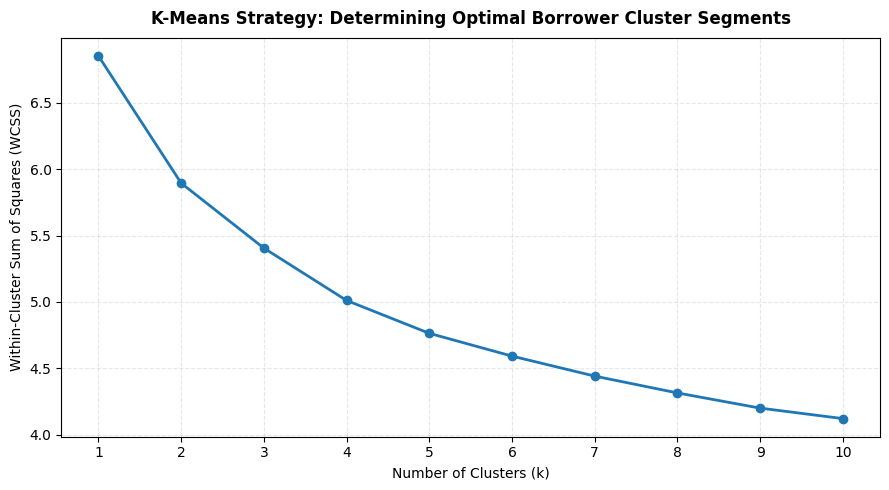

Elbow curve rendered successfully. Identify the inflection vertex to lock in k!


In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print("---  Executing High-Performance WCSS Iteration Loop ---")

wcss = []

# Test cluster partitions from 1 to 10 using the smart k-means++ centroid initializer
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(shap_matrix_np)
    wcss.append(kmeans.inertia_)

# =====================================================================
#  RENDERING THE STRATEGIC ELBOW PROFILE GRAPH
# =====================================================================
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='#1f77b4', linewidth=2)

plt.title("K-Means Strategy: Determining Optimal Borrower Cluster Segments", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Number of Clusters (k)", fontsize=10)
plt.ylabel("Within-Cluster Sum of Squares (WCSS)", fontsize=10)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("Elbow curve rendered successfully. Identify the inflection vertex to lock in k!")


---  Executing High-Performance Silhouette Evaluation Loop ---


   ↳ Finished k=2 | Average Silhouette Score: 0.1439
   ↳ Finished k=3 | Average Silhouette Score: 0.1537
   ↳ Finished k=4 | Average Silhouette Score: 0.1468
   ↳ Finished k=5 | Average Silhouette Score: 0.1347
   ↳ Finished k=6 | Average Silhouette Score: 0.1357
   ↳ Finished k=7 | Average Silhouette Score: 0.1330
   ↳ Finished k=8 | Average Silhouette Score: 0.0849
   ↳ Finished k=9 | Average Silhouette Score: 0.0870
   ↳ Finished k=10 | Average Silhouette Score: 0.0820


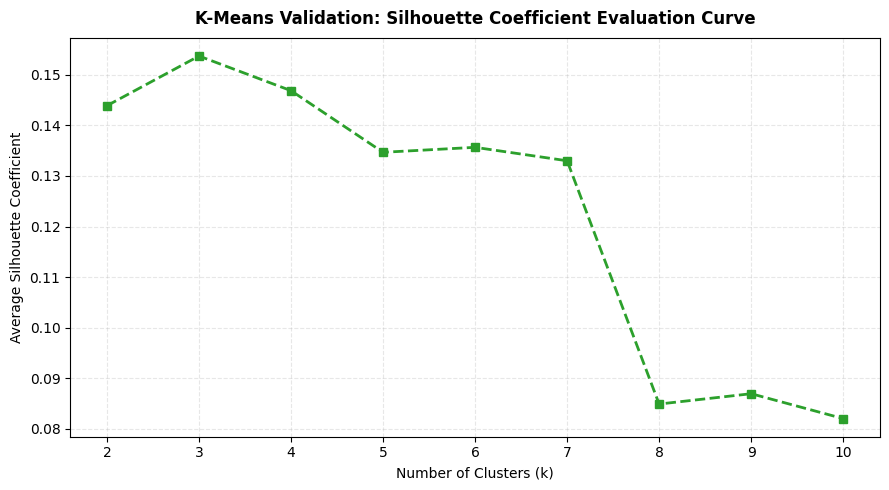

Silhouette optimization graph rendered successfully. Evaluate the score peaks!


In [6]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

print("---  Executing High-Performance Silhouette Evaluation Loop ---")

silhouette_scores = []
# Silhouette requires at least 2 partitions to compute cross-border separation distances
cluster_range = range(2, 11)

# Test cluster partitions from 2 to 10 using the smart k-means++ centroid initializer
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(shap_matrix_np)
    
    # Calculate the mean silhouette width across all 5,000 audited profiles
    score = silhouette_score(shap_matrix_np, labels)
    silhouette_scores.append(score)
    print(f"   ↳ Finished k={k} | Average Silhouette Score: {score:.4f}")

# =====================================================================
#  RENDERING THE SILHOUETTE PROFILE GRAPH
# =====================================================================
plt.figure(figsize=(9, 5))
plt.plot(cluster_range, silhouette_scores, marker='s', linestyle='--', color='#2ca02c', linewidth=2)

plt.title("K-Means Validation: Silhouette Coefficient Evaluation Curve", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Number of Clusters (k)", fontsize=10)
plt.ylabel("Average Silhouette Coefficient", fontsize=10)
plt.xticks(cluster_range)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("Silhouette optimization graph rendered successfully. Evaluate the score peaks!")


In [8]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

print("---  Phase 7: Fitting Production K-Means Engine (k=3) ---")

# 1. Initialize and fit the final model with your selected peak silhouette value
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Generate the cluster assignments (0, 1, 2) for your 5,000 audited profiles
cluster_assignments = kmeans_final.fit_predict(shap_matrix_np)

---  Phase 7: Fitting Production K-Means Engine (k=3) ---


In [9]:
cluster_assignments

array([2, 2, 1, ..., 2, 1, 1], shape=(5000,), dtype=int32)

In [10]:
# 2. Load the raw unscaled features to build our human-readable audit profile
X_raw_global = pd.read_parquet("X_train_raw.parquet", engine='fastparquet')
X_raw_audit = X_raw_global.loc[X_shap_sample.index].copy()

# 3. Assemble the Master Unified Audit DataFrame
master_audit_df = X_raw_audit.copy()
master_audit_df['cluster_id'] = cluster_assignments
master_audit_df['baseline_residual'] = y_shap_residuals.values

# 4. Clean numerical columns inside the audit frame to ensure stable math averages
numeric_cols = ['int_rate', 'loan_amnt', 'annual_inc', 'bc_util', 'dti']
for col in numeric_cols:
    if col in master_audit_df.columns:
        master_audit_df[col] = pd.to_numeric(master_audit_df[col], errors='coerce')

print(f"Success! Master evaluation matrix compiled with shapes: {master_audit_df.shape}")
print("Cluster segments successfully distributed across your 5,000 profile records.")

Success! Master evaluation matrix compiled with shapes: (5000, 62)
Cluster segments successfully distributed across your 5,000 profile records.


In [11]:
print("---  Compiling MRMG Independent Segment Performance Table ---")

# Compute the global averages per cluster ID to find systematic miscalculations
summary_table = master_audit_df.groupby('cluster_id').agg(
    volume=('baseline_residual', 'count'),
    avg_loan_amnt=('loan_amnt', 'mean'),
    avg_int_rate=('int_rate', 'mean'),
    avg_annual_inc=('annual_inc', 'mean'),
    avg_bc_util=('bc_util', 'mean'),
    avg_dti=('dti', 'mean'),
    mean_baseline_residual=('baseline_residual', 'mean')
).reset_index()

# Round numbers nicely for formal report tracking layout
summary_table = summary_table.round({
    'avg_loan_amnt': 2, 'avg_int_rate': 2, 'avg_annual_inc': 2, 
    'avg_bc_util': 2, 'avg_dti': 2, 'mean_baseline_residual': 4
})

print("\n THE FINAL MODEL WEAK-SPOTS AUDIT MATRIX:")
display(summary_table)


---  Compiling MRMG Independent Segment Performance Table ---

 THE FINAL MODEL WEAK-SPOTS AUDIT MATRIX:


,cluster_id,volume,avg_loan_amnt,avg_int_rate,avg_annual_inc,avg_bc_util,avg_dti,mean_baseline_residual
0,0,360,3731.18,14.07,44862.22,52.85,16.1,-0.0359
1,1,2295,15072.54,11.64,85091.6,55.92,17.13,-0.0116
2,2,2345,15942.73,15.11,73100.78,65.9,19.66,0.0216


---  Rendering MRMG Cluster Segmentation Presentation Chart ---


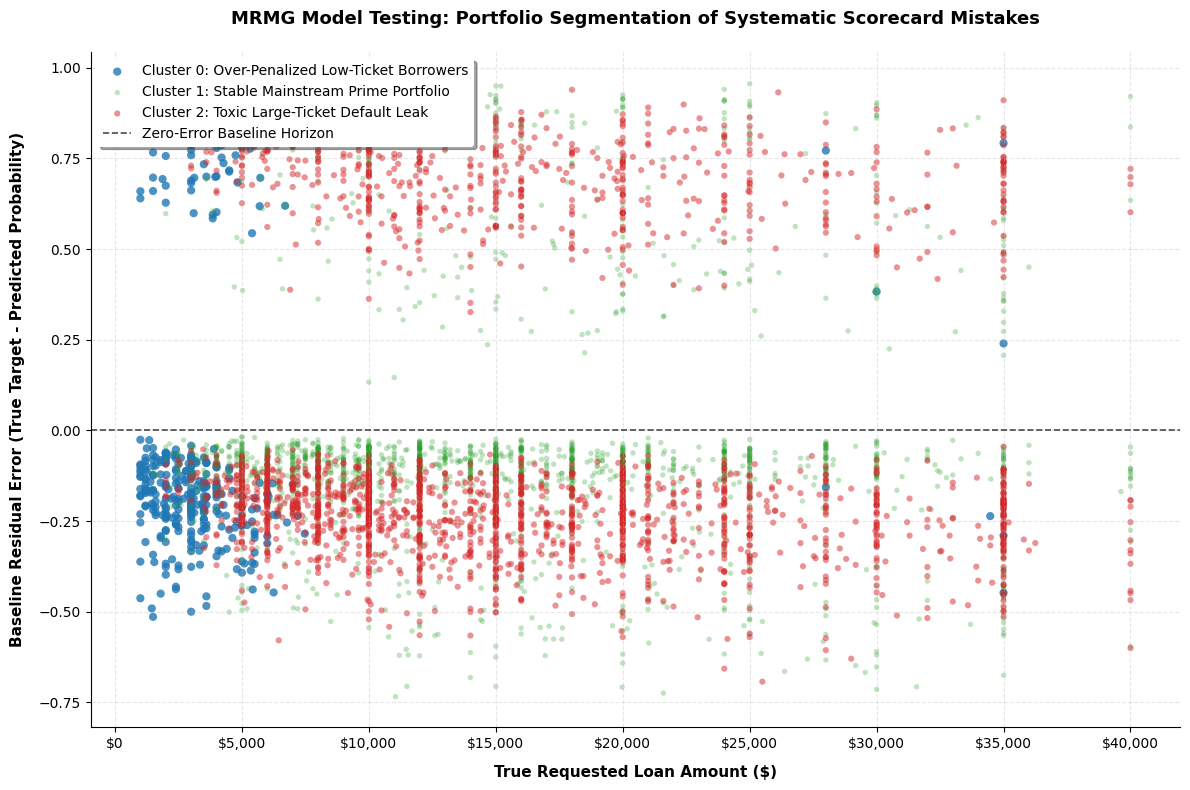

Presentation scatter visualization successfully rendered.


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("---  Rendering MRMG Cluster Segmentation Presentation Chart ---")

plt.figure(figsize=(12, 8))
ax = plt.subplot(111)

# 1. Define clean institutional colors and explicit business labels for each population
cluster_meta = {
    0: {'color': '#1f77b4', 'label': 'Cluster 0: Over-Penalized Low-Ticket Borrowers', 'alpha': 0.8, 'size': 35},
    1: {'color': '#2ca02c', 'label': 'Cluster 1: Stable Mainstream Prime Portfolio', 'alpha': 0.3, 'size': 15},
    2: {'color': '#d62728', 'label': 'Cluster 2: Toxic Large-Ticket Default Leak', 'alpha': 0.5, 'size': 20}
}

# 2. Iterate through each unique cluster partition and map points sequentially
for c_id, meta in cluster_meta.items():
    cluster_subset = master_audit_df[master_audit_df['cluster_id'] == c_id]
    
    plt.scatter(
        cluster_subset['loan_amnt'], 
        cluster_subset['baseline_residual'],
        c=meta['color'],
        label=meta['label'],
        s=meta['size'],
        alpha=meta['alpha'],
        edgecolors='none'
    )

# 3. Add a distinct mathematical baseline horizon line at Y=0
# Points above this line are missed defaults; points below are over-penalized safe loans
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7, label='Zero-Error Baseline Horizon')

# 4. Formatting and structural layout polish
plt.xlabel("True Requested Loan Amount ($)", fontsize=11, labelpad=10, fontweight='bold')
plt.ylabel("Baseline Residual Error (True Target - Predicted Probability)", fontsize=11, labelpad=10, fontweight='bold')
plt.title("MRMG Model Testing: Portfolio Segmentation of Systematic Scorecard Mistakes", fontsize=13, fontweight='bold', pad=20)

# Position the legend box cleanly at the upper left quadrant
plt.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='none', shadow=True)

# Add standard regulatory presentation grids
plt.grid(True, linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Clean numeric tick formatter adjustments for dollar scales
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

print("Presentation scatter visualization successfully rendered.")


In [19]:
pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [18]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

print("---  Compiling Interactive 3D Portfolio Risk Universe ---")

# 1. Create a clean, unscaled tracking dataframe strictly for 3D layout bounds
df_3d = master_audit_df.copy()

# Cap the annual income axis dynamically at $250k strictly for visual mapping 
# This filters out that single $8M outlier so it doesn't squash your 3D view
df_3d = df_3d[df_3d['annual_inc'] <= 250000]

# 2. Map explicit metadata profiles for each population segment
cluster_metadata = {
    0: {'color': '#1f77b4', 'name': 'Cluster 0: Over-Penalized Low-Ticket', 'size': 5},
    1: {'color': '#2ca02c', 'name': 'Cluster 1: Stable Mainstream Prime', 'size': 3},
    2: {'color': '#d62728', 'name': 'Cluster 2: Toxic Large-Ticket Leak', 'size': 4}
}

fig = go.Figure()

# 3. Build individual 3D scatter traces sequentially per cluster
for c_id, meta in cluster_metadata.items():
    sub = df_3d[df_3d['cluster_id'] == c_id]
    
    fig.add_trace(go.Scatter3d(
        x=sub['loan_amnt'],
        y=sub['annual_inc'],
        z=sub['baseline_residual'],
        mode='markers',
        name=meta['name'],
        marker=dict(
            size=meta['size'],
            color=meta['color'],
            opacity=0.7 if c_id != 1 else 0.3, # Keeps the stable cluster faint to emphasize errors
            line=dict(width=0)
        ),
        # Interactive hover text template display format
        hovertemplate=(
            "<b>%{text}</b><br><br>" +
            "Loan Amount: $%{x:,.0f}<br>" +
            "Annual Income: $%{y:,.0f}<br>" +
            "Model Error: %{z:.4f}<extra></extra>"
        ),
        text=[f"Borrower ID: {idx}" for idx in sub.index]
    ))

# 4. Inject a flat zero-error grid horizon plane to map structural directions
x_range = np.linspace(df_3d['loan_amnt'].min(), df_3d['loan_amnt'].max(), 10)
y_range = np.linspace(df_3d['annual_inc'].min(), df_3d['annual_inc'].max(), 10)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z_grid = np.zeros_like(X_grid)

fig.add_trace(go.Surface(
    x=x_range,
    y=y_range,
    z=Z_grid,
    showscale=False,
    opacity=0.2,
    colorscale=[[0, 'gray'], [1, 'gray']],
    name='Zero-Error Horizon'
))

# 5. Clean layout formatting polish for institutional presentation standards
fig.update_layout(
    title=dict(
        text="MRMG 3D Audit Space: Multi-Variable Interaction Risk Universe",
        x=0.5, y=0.95, font=dict(size=14, color='white')
    ),
    scene=dict(
        xaxis=dict(title="Loan Amount ($)", backgroundcolor="rgb(20, 20, 20)", gridcolor="gray", showbackground=True),
        yaxis=dict(title="Annual Income ($)", backgroundcolor="rgb(20, 20, 20)", gridcolor="gray", showbackground=True),
        zaxis=dict(title="Baseline Residual", backgroundcolor="rgb(20, 20, 20)", gridcolor="gray", showbackground=True)
    ),
    template="plotly_dark", # Sleek presentation contrast theme
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(yanchor="top", y=0.95, xanchor="left", x=0.05)
)

# Force Plotly to output via your local browser engine, bypassing the notebook mime trap entirely
fig.show(renderer="browser")

fig.show()
print("Interactive 3D model successfully initialized inside your active cell window.")


---  Compiling Interactive 3D Portfolio Risk Universe ---


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [20]:
import pandas as pd
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

print("---  Initializing Enterprise Excel Report Engine ---")

# 1. Prepare clean presentable column names for the executive committee
report_df = summary_table.copy()
report_df.columns = [
    "Cluster Segment ID", "Audited Loan Volume", "Avg Requested Loan Amount",
    "Avg Interest Rate", "Avg Annual Income", "Avg Bankcard Utilization",
    "Avg Debt-to-Income (DTI)", "Mean Baseline Model Error (Residual)"
]

# 2. Export the data to a raw excel workspace file
file_name = "MRMG_Model_Weak_Spots_Audit_Report.xlsx"
report_df.to_excel(file_name, index=False)

# 3. Re-open the file via openpyxl to inject professional visual styles
wb = openpyxl.load_workbook(file_name)
ws = wb.active
ws.title = "Model Weak-Spots Audit Matrix"

# =====================================================================
#  DEFINE REGULATORY PRESENTATION STYLES (Navy Theme)
# =====================================================================
font_title = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
font_header = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
font_data = Font(name="Calibri", size=11, bold=False, color="000000")

fill_title = PatternFill(start_color="1B365D", end_color="1B365D", fill_type="solid") # Dark Navy
fill_header = PatternFill(start_color="2A4B7C", end_color="2A4B7C", fill_type="solid") # Medium Slate Navy
fill_zebra = PatternFill(start_color="F2F5F9", end_color="F2F5F9", fill_type="solid") # Light Slate Tint

align_center = Alignment(horizontal="center", vertical="center", wrap_text=True)
align_left = Alignment(horizontal="left", vertical="center", wrap_text=True)
align_right = Alignment(horizontal="right", vertical="center", wrap_text=True)

thin_side = Side(border_style="thin", color="D3D3D3")
border_cell = Border(left=thin_side, right=thin_side, top=thin_side, bottom=thin_side)

# =====================================================================
#  INJECT STRUCTURAL SHEET GRID FORMATTING
# =====================================================================
# Create a dominant corporate title banner row at the top
ws.insert_rows(1, 2)
ws.merge_cells("A1:H1")
ws["A1"] = "MODEL RISK MANAGEMENT GROUP (MRMG) independent Model Testing Framework"
ws["A1"].font = font_title
ws["A1"].fill = fill_title
ws["A1"].alignment = Alignment(horizontal="left", vertical="center", indent=1)
ws.row_dimensions[1].height = 40

# Format the column data headers (now on Row 3)
ws.row_dimensions[3].height = 28
for col_num in range(1, 9):
    cell = ws.cell(row=3, column=col_num)
    cell.font = font_header
    cell.fill = fill_header
    cell.alignment = align_center
    cell.border = border_cell

# Format data text grids, numerical patterns, and rows (Rows 4 through 6)
for row_num in range(4, 7):
    ws.row_dimensions[row_num].height = 22
    for col_num in range(1, 9):
        cell = ws.cell(row=row_num, column=col_num)
        cell.font = font_data
        cell.border = border_cell
        
        # Zebra striping: alternate background shading on even data rows
        if row_num % 2 == 0:
            cell.fill = fill_zebra
            
        # Apply strict financial alignment and precision masks based on the column
        if col_num in [1, 2]: # Cluster ID, Volume
            cell.alignment = align_center
            if col_num == 2:
                cell.number_format = '#,##0'
        elif col_num in [3, 5]: # Currencies (Loan Amt, Income)
            cell.alignment = align_right
            cell.number_format = '$#,##0.00'
        elif col_num in [4, 6, 7]: # Percentages (Rates, Util, DTI)
            cell.alignment = align_right
            cell.number_format = '0.00"%"'
        elif col_num == 8: # Six-decimal continuous error metrics
            cell.alignment = align_right
            cell.number_format = '0.0000'

# Dynamically adjust column widths based on cell text length to prevent text clipping
for col in ws.columns:
    max_len = 0
    col_letter = get_column_letter(col[0].column)
    for cell in col:
        # Ignore the giant merged title bar line when calculating standard width limits
        if cell.row == 1:
            continue
        if cell.value is not None:
            max_len = max(max_len, len(str(cell.value)))
    ws.column_dimensions[col_letter].width = max(max_len + 4, 14)

# 4. Save the formatted changes back into your local workspace folder
wb.save(file_name)
print(f"\n🎉 Executive Report successfully generated: '{file_name}'")
print("The file is formatted to strict banking standards and ready for presentation.")


---  Initializing Enterprise Excel Report Engine ---

🎉 Executive Report successfully generated: 'MRMG_Model_Weak_Spots_Audit_Report.xlsx'
The file is formatted to strict banking standards and ready for presentation.
